Importing libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading combined data

In [3]:
df = pd.read_csv("../data/all_countries_clean.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,ethiopia,2015-01-05,1


Verifying countries

In [4]:
df["Country"].unique()

<StringArray>
['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
Length: 5, dtype: str

Aggregating by country

In [5]:
country_stats = df.groupby("Country").agg({
    "T2M": "mean",
    "PRECTOTCORR": "mean",
    "RH2M": "mean"
}).reset_index()

country_stats

,Country,T2M,PRECTOTCORR,RH2M
0,ethiopia,16.096771,3.016690,68.315885
1,kenya,20.450133,1.100035,65.568779
2,nigeria,26.735115,3.645836,85.872586
3,sudan,28.793320,0.321469,30.678091
4,tanzania,26.802536,2.939913,76.995370


Temperature

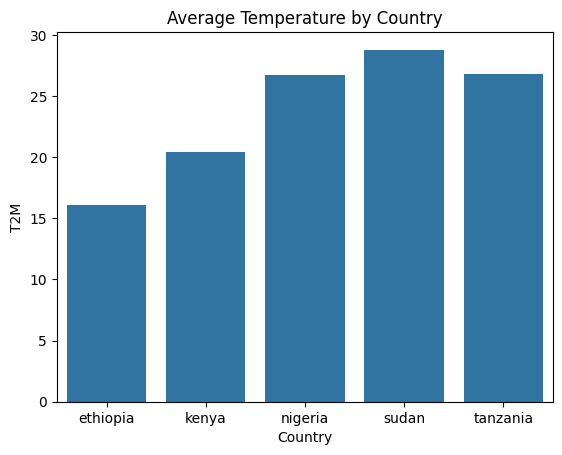

In [6]:
sns.barplot(x="Country", y="T2M", data=country_stats)
plt.title("Average Temperature by Country")
plt.show()

Precipitation

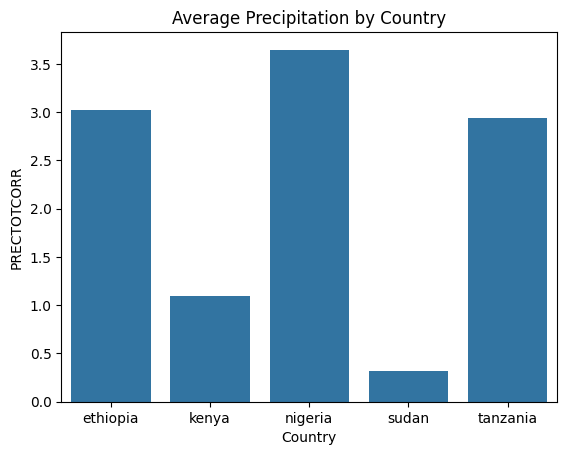

In [7]:
sns.barplot(x="Country", y="PRECTOTCORR", data=country_stats)
plt.title("Average Precipitation by Country")
plt.show()

Defining a score

In [8]:
country_stats["vulnerability_score"] = (
    country_stats["T2M"] * 0.4 +
    country_stats["PRECTOTCORR"] * 0.3 +
    country_stats["RH2M"] * 0.3
)

Sorting

In [9]:
ranking = country_stats.sort_values(by="vulnerability_score", ascending=False)
ranking

,Country,T2M,PRECTOTCORR,RH2M,vulnerability_score
2,nigeria,26.735115,3.645836,85.872586,37.549572
4,tanzania,26.802536,2.939913,76.995370,34.701599
1,kenya,20.450133,1.100035,65.568779,28.180697
0,ethiopia,16.096771,3.016690,68.315885,27.838481
3,sudan,28.793320,0.321469,30.678091,20.817196


Saving ranking

In [10]:
ranking.to_csv("../data/vulnerability_ranking.csv", index=False)